In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

# Load dataset
data = load_diabetes()

# Features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Original continuous target
y_original = data.target

# Convert target into binary classes
# 1 = Diabetes, 0 = No Diabetes
y = (y_original > np.median(y_original)).astype(int)

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(X.head())

print("\nDataset shape:")
print(X.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nClass distribution:")
print(pd.Series(y).value_counts())

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\ADS2609024\AppData\Local\miniconda3\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


Dataset loaded successfully!

First 5 rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Dataset shape:
(442, 10)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Class distribution:
1    221
0    221
Name: count, dtype: int64


In [4]:
print("\nFeature Information:")
print(X.info())

print("\nStatistical Summary:")
print(X.describe())


Feature Information:
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None

Statistical Summary:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.1239

In [5]:
df = X.copy()
df["Diagnosis"] = y

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Diagnosis  
0 -0.002592  0.019907 -0.017646          1  
1 -0.039493 -0.068332 -0.092204          0  
2 -0.002592  0.002861 -0.025930          1  
3  0.034309  0.022688 -0.009362          1  
4 -0.002592 -0.031988 -0.046641          0  


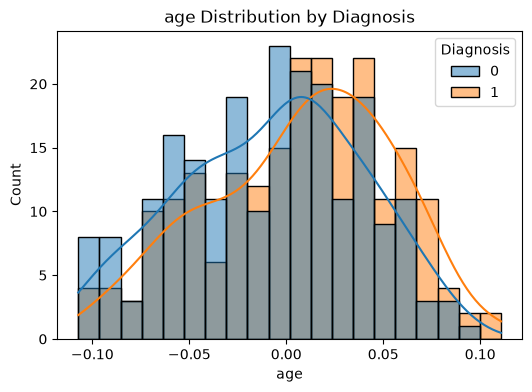

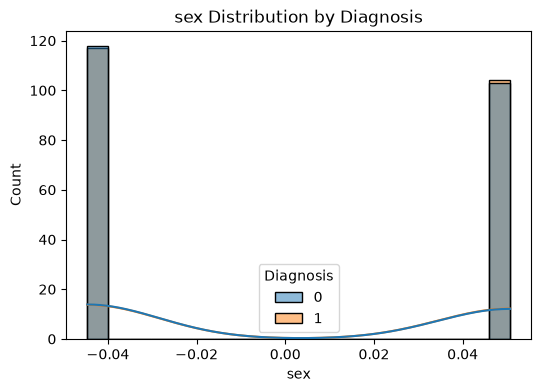

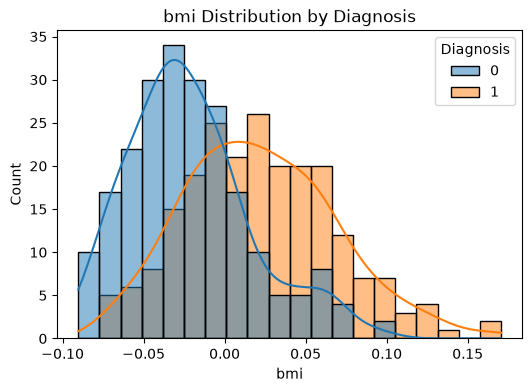

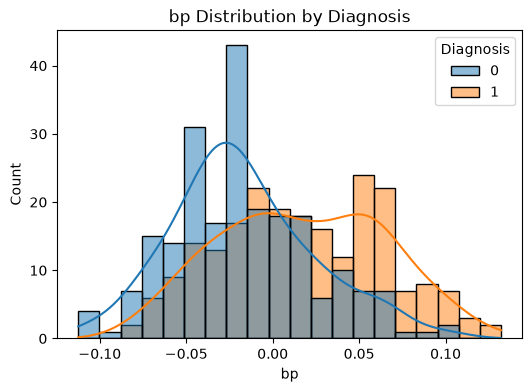

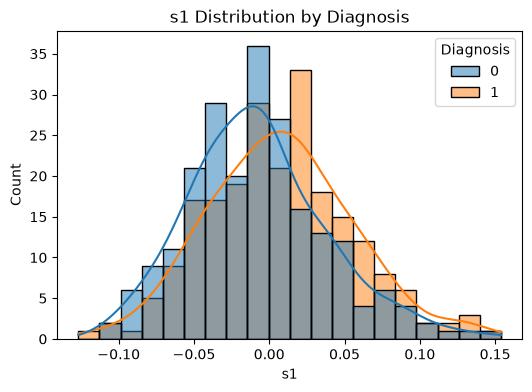

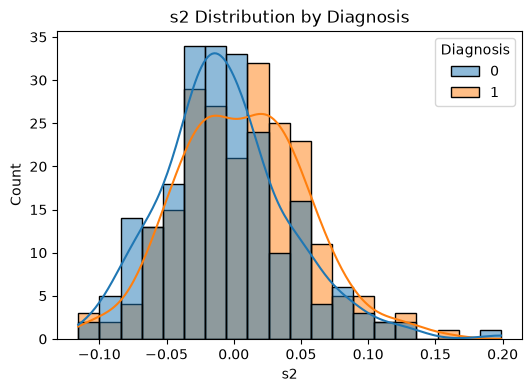

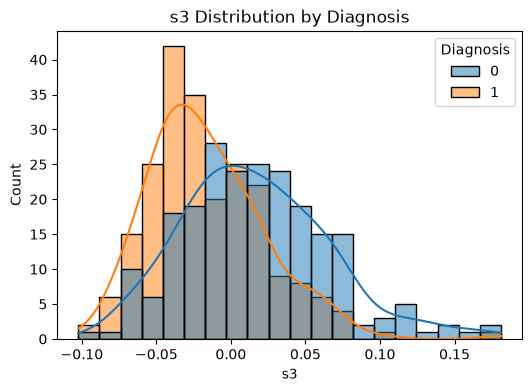

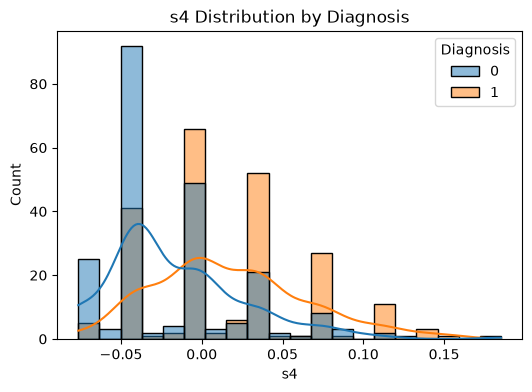

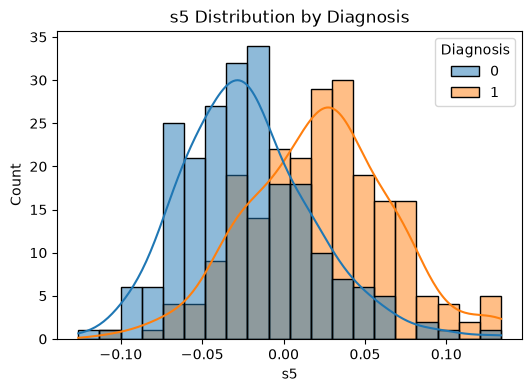

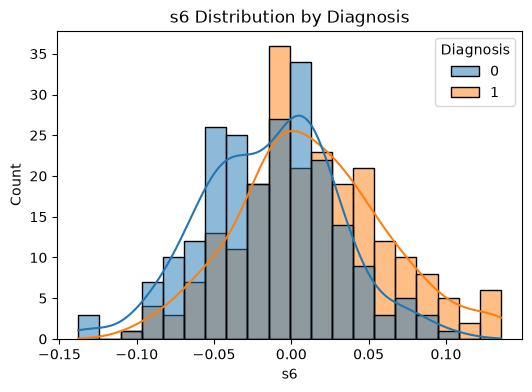

In [6]:
for feature in X.columns:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Diagnosis",
        kde=True,
        bins=20
    )

    plt.title(feature + " Distribution by Diagnosis")
    plt.show()

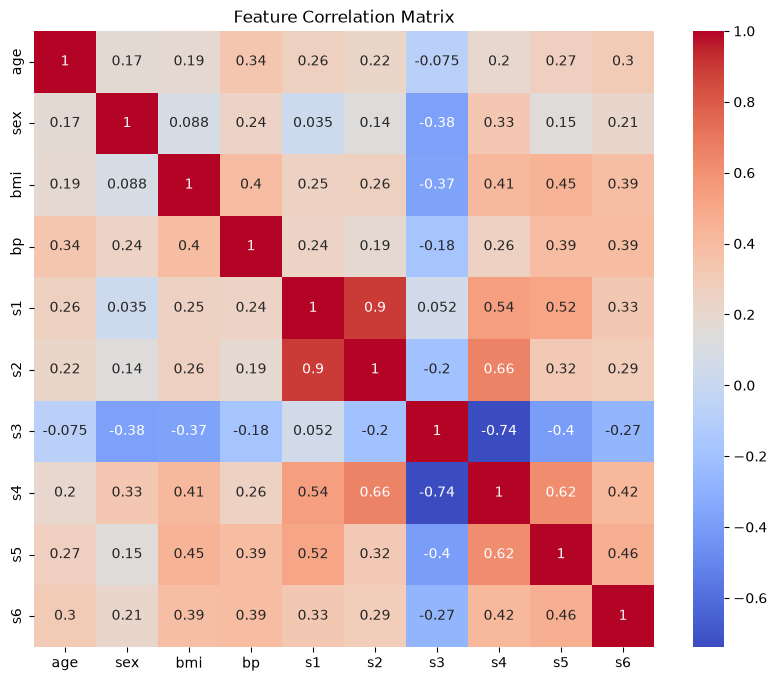

In [7]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

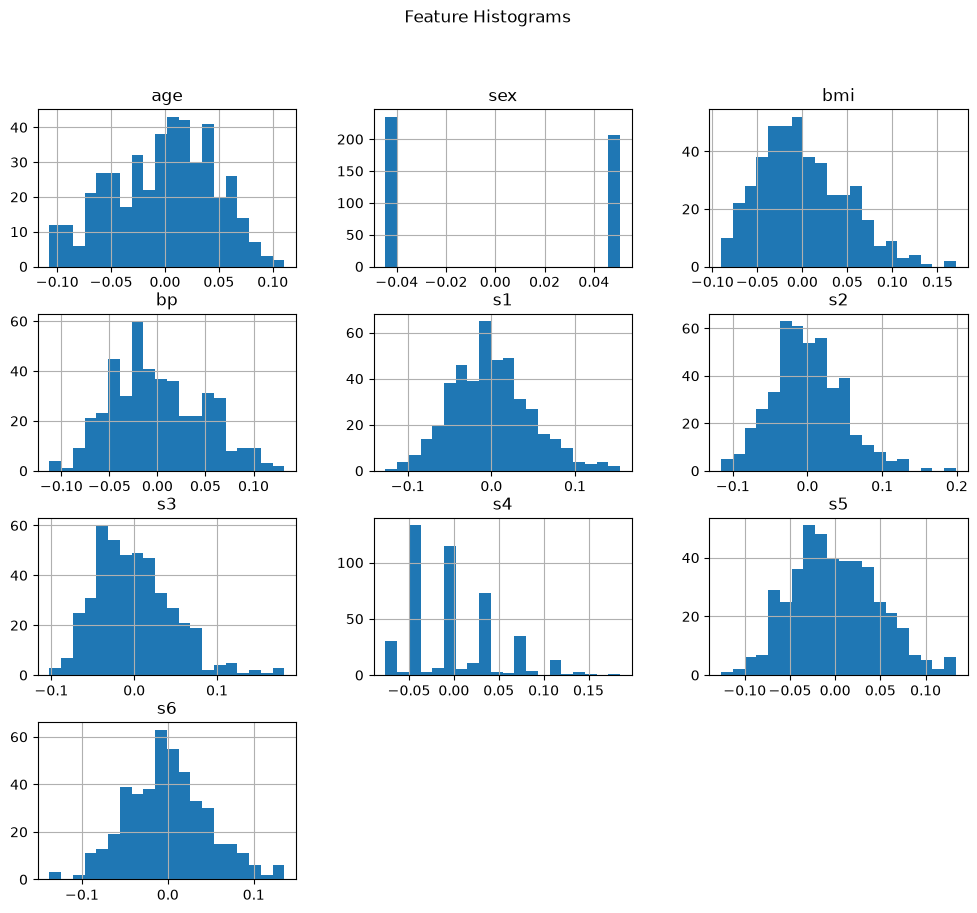

In [8]:
X.hist(
    figsize=(12, 10),
    bins=20
)

plt.suptitle("Feature Histograms")
plt.show()

In [9]:
def multivariate_gaussian_pdf(x, mean, covariance):
    
    x = np.array(x)
    mean = np.array(mean)
    covariance = np.array(covariance)

    n = len(mean)

    covariance_inv = np.linalg.inv(covariance)

    determinant = np.linalg.det(covariance)

    exponent = -0.5 * np.dot(
        np.dot((x - mean), covariance_inv),
        (x - mean)
    )

    coefficient = 1 / np.sqrt(
        (2 * np.pi) ** n * determinant
    )

    return coefficient * np.exp(exponent)

In [10]:
mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

x = np.array([0, 0])

probability = multivariate_gaussian_pdf(
    x,
    mean,
    covariance
)

print("Gaussian PDF value:", probability)

Gaussian PDF value: 0.15915494309189535


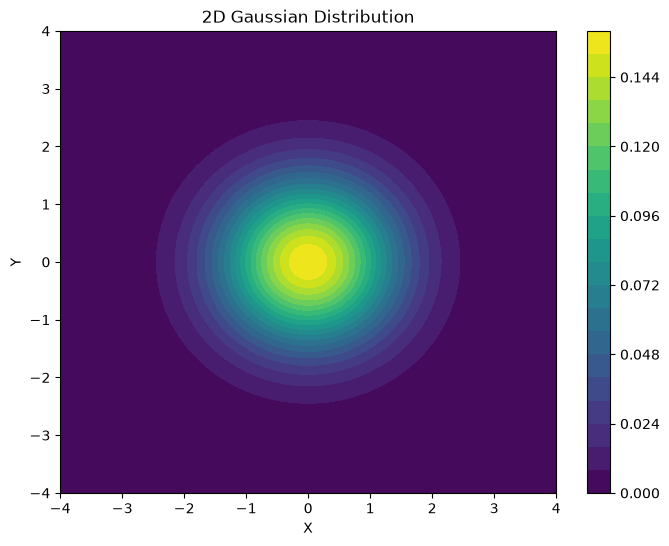

In [11]:
x = np.linspace(-4, 4, 100)
y_grid = np.linspace(-4, 4, 100)

X_grid, Y_grid = np.meshgrid(x, y_grid)

mean = np.array([0, 0])

covariance = np.array([
    [1, 0],
    [0, 1]
])

Z = np.zeros(X_grid.shape)

for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        point = np.array([
            X_grid[i, j],
            Y_grid[i, j]
        ])

        Z[i, j] = multivariate_gaussian_pdf(
            point,
            mean,
            covariance
        )

plt.figure(figsize=(8, 6))

plt.contourf(
    X_grid,
    Y_grid,
    Z,
    levels=20
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Gaussian Distribution")
plt.colorbar()

plt.show()

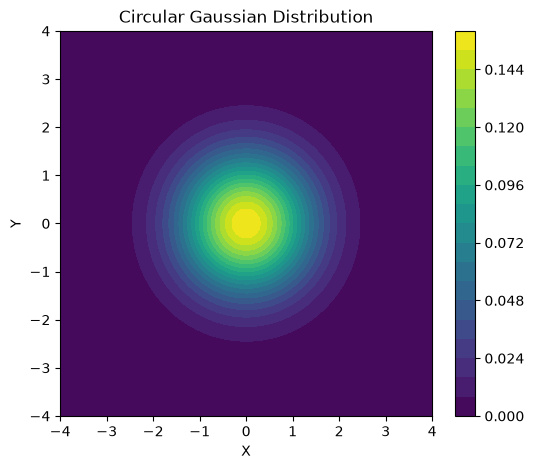

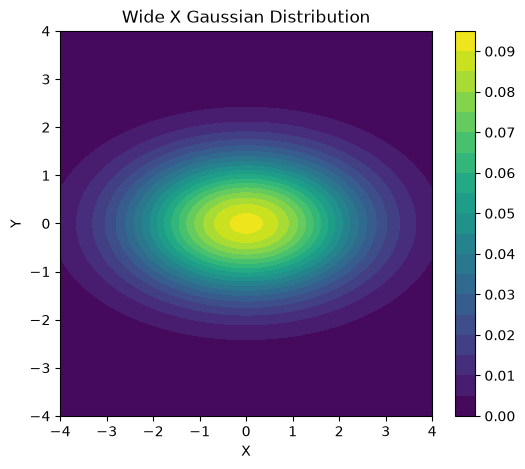

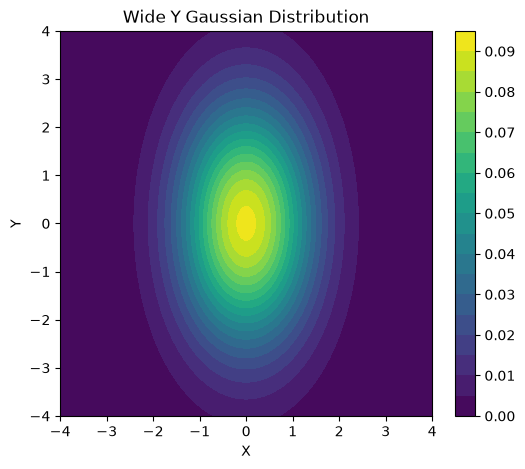

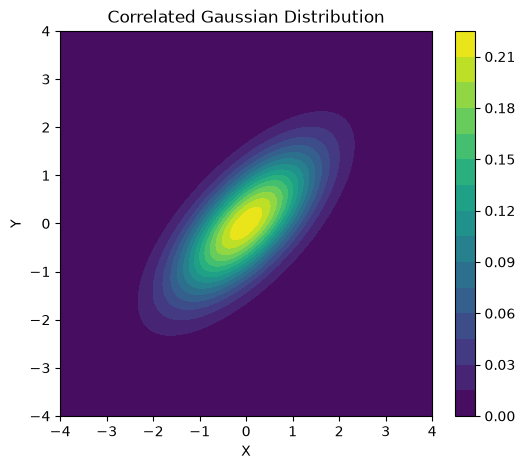

In [12]:
cov4 = np.array([
    [1, 0.7],
    [0.7, 1]
])

cov3 = np.array([
    [1, 0],
    [0, 3]
])

cov2 = np.array([
    [3, 0],
    [0, 1]
])

cov1 = np.array([
    [1, 0],
    [0, 1]
])

covariances = [
    cov1,
    cov2,
    cov3,
    cov4
]

titles = [
    "Circular",
    "Wide X",
    "Wide Y",
    "Correlated"
]

for covariance, title in zip(covariances, titles):

    Z = np.zeros(X_grid.shape)

    for i in range(X_grid.shape[0]):
        for j in range(X_grid.shape[1]):

            point = np.array([
                X_grid[i, j],
                Y_grid[i, j]
            ])

            Z[i, j] = multivariate_gaussian_pdf(
                point,
                mean,
                covariance
            )

    plt.figure(figsize=(6, 5))

    plt.contourf(
        X_grid,
        Y_grid,
        Z,
        levels=20
    )

    plt.title(title + " Gaussian Distribution")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.colorbar()

    plt.show()